# **Taller 05: Clustering DBScan**

**Inteligencia Artificial ELP 8012 - Universidad del Norte - Profesor: Eduardo Zurek, PH.D.**

**Grupo:** Paula Núñez, Isabella Arrieta y Natalia Carpintero

Diseñe e implemente un algoritmo de clustering DBScan que reciba como entrada un conjunto de datos sintéticos en dos dimensiones generados a partir de una figura que contenga grupos amorfos.

En este notebook se usa la imagen base de la carpeta IMG/our_image.png, se generan puntos 2D a partir de sus regiones amorfas, se agregan outliers uniformes y se aplica DBSCAN con análisis exploratorio de k-distancia y evaluación del desempeño.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from scipy import ndimage
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


Imagen base: C:\Users\NATALIA\Documents\Clases Universidad\IA\Taller-05-Clustering-DBScan\IMG\our_image.png
Dimensiones de la imagen: 1152 x 648
Número de regiones detectadas: 82


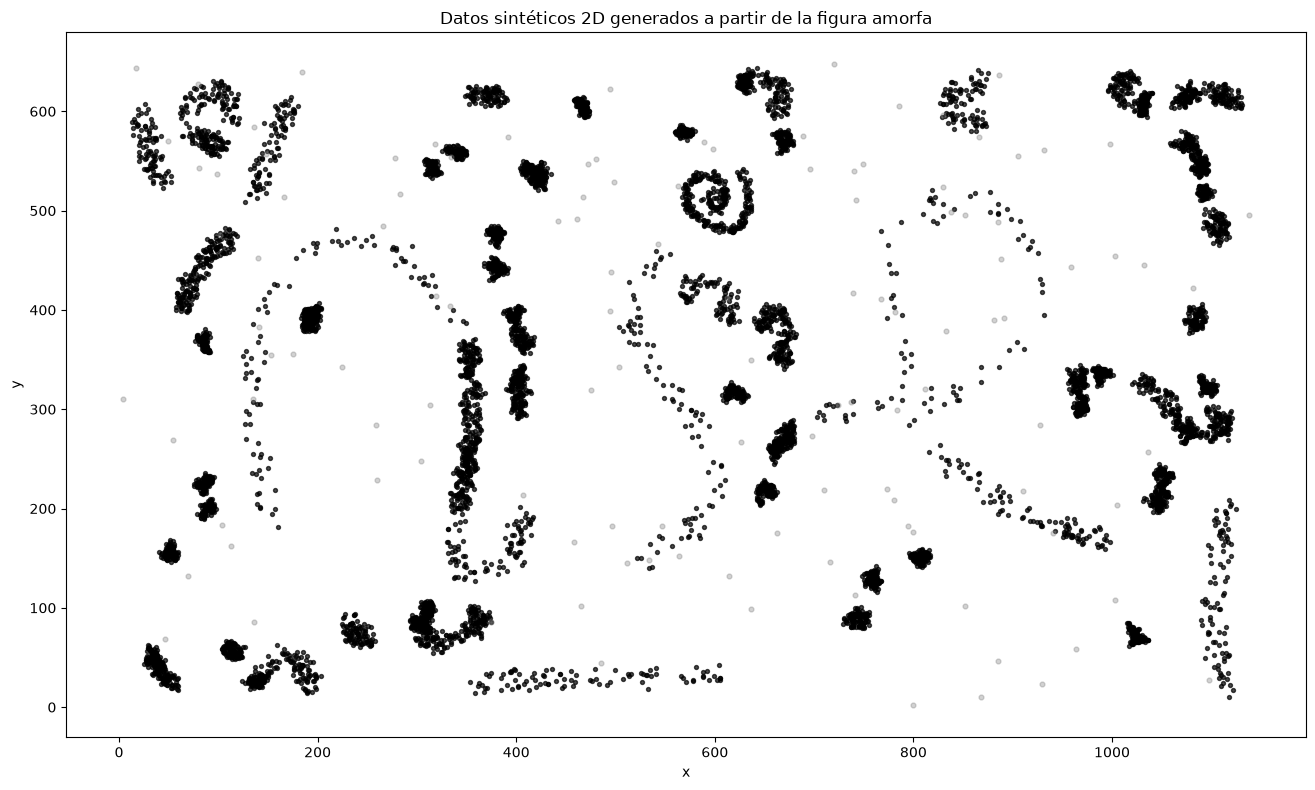

,x,y
0,397.721120,38.669797
1,370.998078,18.852272
2,525.365053,33.880423
3,570.468998,24.829331
4,427.015951,32.504130


In [ ]:
plt.style.use("default")

IMG_PATH = Path("IMG/our_image.png")
print(f"Imagen base: {IMG_PATH.resolve()}")
img = np.array(Image.open(IMG_PATH).convert("L"))
img=np.flipud(img)
print(f"Dimensiones de la imagen: {img.shape[1]} x {img.shape[0]}")

# Convertimos la imagen en una máscara binaria: fondo blanco, grupos negros.
mask = img < 200
labeled, n_regions = ndimage.label(mask)

# Se filtran regiones muy pequeñas para descartar ruido y mantener grupos amorfos.
min_region_size = 80
valid_regions = []
for region_id in range(1, n_regions + 1):
    ys, xs = np.where(labeled == region_id)
    if len(xs) >= min_region_size:
        valid_regions.append(np.column_stack([xs.astype(float), ys.astype(float)]))

print(f"Número de regiones detectadas: {len(valid_regions)}")

# Muestreo aleatorio de puntos por región para crear el conjunto sintético.
rng = np.random.default_rng(42)
cluster_samples = []
for region_points in valid_regions:
    n_points = min(90, len(region_points))
    idx = rng.choice(len(region_points), size=n_points, replace=False)
    sampled = region_points[idx]
    jitter = rng.normal(0, 1.5, size=sampled.shape)
    cluster_samples.append(sampled + jitter)

# Se agregan outliers uniformes en el espacio 2D.
width, height = img.shape[1], img.shape[0]
outliers = rng.uniform([0, 0], [width, height], size=(120, 2))

X = np.vstack(cluster_samples + [outliers])
true_cluster_ids = []
for i in range(len(cluster_samples)):
    true_cluster_ids.append(np.full(len(cluster_samples[i]), i))
true_labels = np.concatenate(true_cluster_ids + [np.full(len(outliers), -1)])

# Visualización de los grupos amorfos generados a partir de la imagen.
fig, ax = plt.subplots(figsize=(14, 8))
for pts in cluster_samples:
    ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.7, c="black")
ax.scatter(outliers[:, 0], outliers[:, 1], s=12, c="gray", alpha=0.35)
ax.set_title("Datos sintéticos 2D generados a partir de la figura amorfa")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
#ax.invert_yaxis()  # Invertimos el eje y para que coincida con la orientación de la imagen.
plt.tight_layout()
plt.show()

X_df = pd.DataFrame(X, columns=["x", "y"])
X_df.head()

Índice del punto de inflexión: 3691
Estimación inicial de epsilon: 78.319


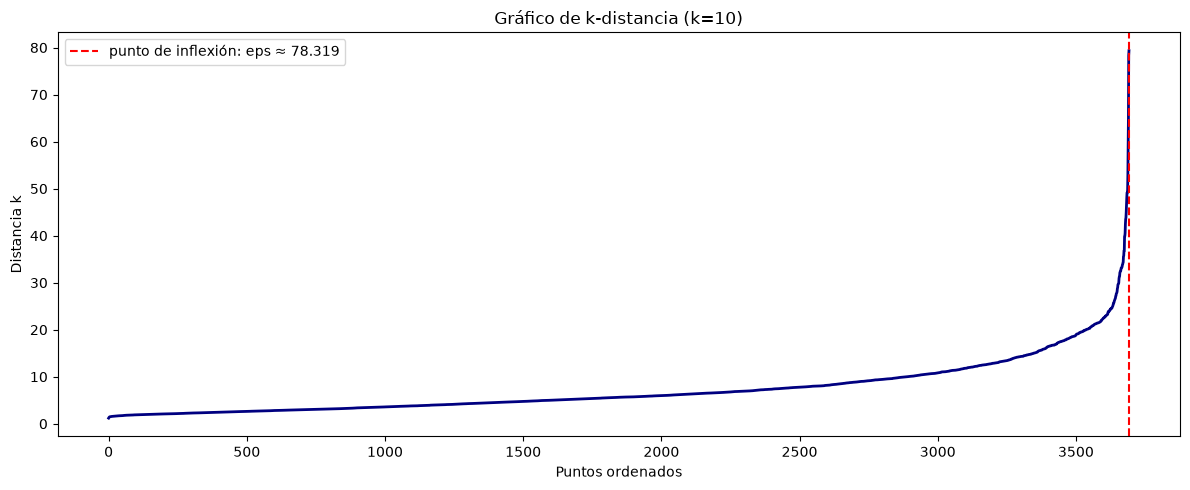

Mejor configuración encontrada por silueta:
{'min_pts': 12.0, 'eps': 4.090909090909091, 'n_clusters': 22.0, 'silhouette': 0.7598060695937839, 'davies_bouldin': 0.3053163850529979, 'calinski_harabasz': 19192.127456250928}
Parámetros recomendados: eps = 4.090909090909091, MinPts = 12


In [16]:
# Análisis exploratorio con gráficos de k-distancia para estimar eps y MinPts.

# Se usa k = 10 para un análisis razonable en 2D.
knn = NearestNeighbors(n_neighbors=10)
knn.fit(X)
dists, _ = knn.kneighbors(X)
k_dist = np.sort(dists[:, -1])

# Punto de inflexión aproximado (elbow) usando la segunda diferencia.
def elbow_point(values):
    if len(values) < 4:
        return 0
    d1 = np.diff(values)
    d2 = np.diff(d1)
    idx = int(np.argmax(np.abs(d2)) + 1)
    return idx, values[idx]

idx_rodilla, eps_approx = elbow_point(k_dist)
print(f"Índice del punto de inflexión: {idx_rodilla}")
print(f"Estimación inicial de epsilon: {eps_approx:.3f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(np.arange(len(k_dist)), k_dist, linewidth=2, color="navy")
ax.axvline(idx_rodilla, color="red", linestyle="--", linewidth=1.5, label=f"punto de inflexión: eps ≈ {eps_approx:.3f}")
ax.set_title("Gráfico de k-distancia (k=10)")
ax.set_xlabel("Puntos ordenados")
ax.set_ylabel("Distancia k")
ax.legend()
plt.tight_layout()
plt.show()

# Búsqueda exploratoria de parámetros razonables para DBSCAN.
# Se usa un espacio de búsqueda más pequeño para reducir el tiempo de ejecución.
min_pts_candidates = [4, 5, 8, 10, 12]
eps_candidates = np.linspace(3, 15, 12)
parameter_scan = []

for min_pts in min_pts_candidates:
    for eps in eps_candidates:
        labels = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(X)
        unique_labels = np.unique(labels)
        if len(unique_labels) < 2:
            continue
        if np.unique(labels == -1).size == 1 and np.all(labels == -1):
            continue

        valid = labels != -1
        if valid.sum() < 10:
            continue

        valid_labels = labels[valid]
        if len(np.unique(valid_labels)) < 2:
            continue  # no se evalúa; no hay 2 clusters

        sil = silhouette_score(X[valid], valid_labels)
        db = davies_bouldin_score(X[valid], valid_labels)
        ch = calinski_harabasz_score(X[valid],valid_labels)

        n_clusters = len(np.unique(labels[valid]))
        parameter_scan.append({
            "min_pts": min_pts,
            "eps": eps,
            "n_clusters": n_clusters,
            "silhouette": sil,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
        })

scan_df = pd.DataFrame(parameter_scan)
if not scan_df.empty:
    best = scan_df.sort_values("silhouette", ascending=False).iloc[0]
    print("Mejor configuración encontrada por silueta:")
    print(best.to_dict())
    best_eps = float(best["eps"])
    best_min_pts = int(best["min_pts"])
else:
    best_eps = float(eps_approx)
    best_min_pts = 8
    print("No se encontró una búsqueda válida; se usa la estimación inicial de eps y MinPts.")

print(f"Parámetros recomendados: eps = {best_eps}, MinPts = {best_min_pts}")

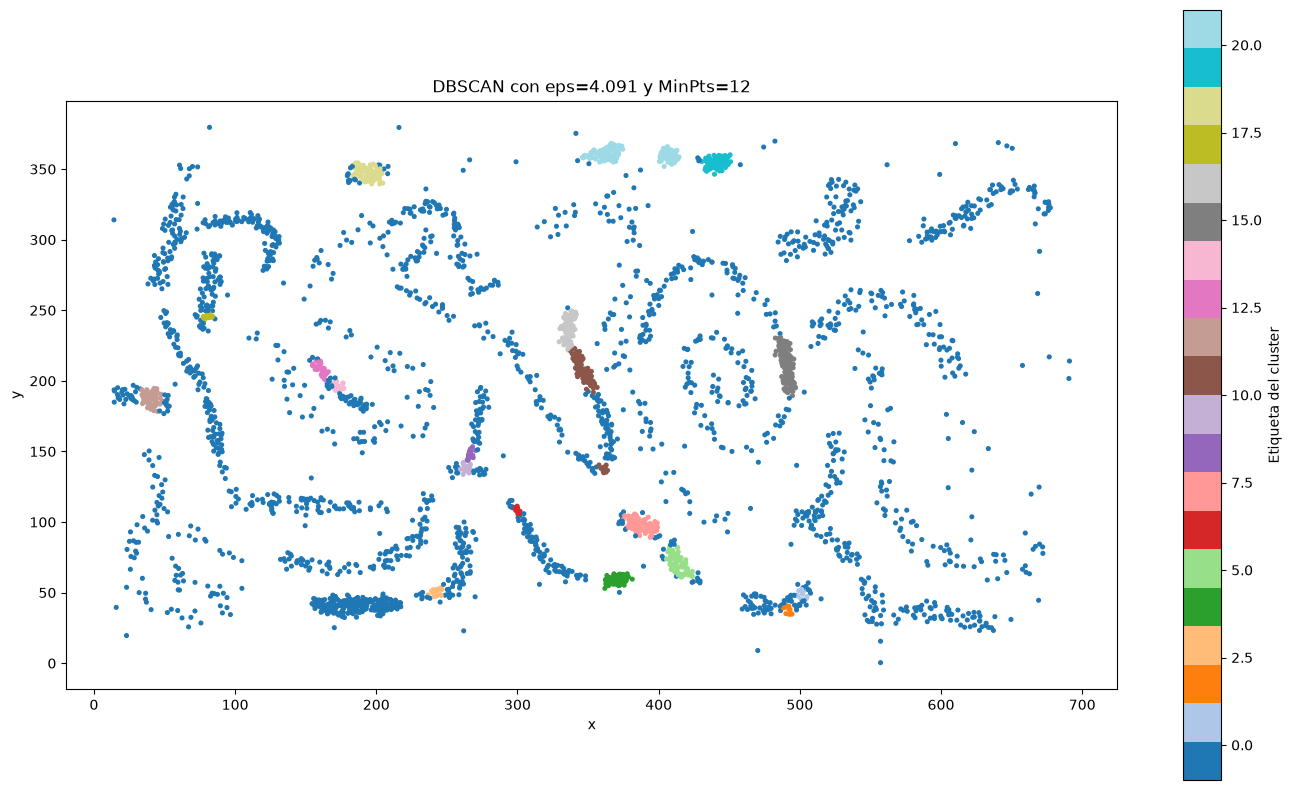

Número de clusters detectados: 22
Número de outliers (-1): 2294


In [17]:
# Ajuste final del modelo DBSCAN con los parámetros seleccionados.
model = DBSCAN(eps=best_eps, min_samples=best_min_pts)
labels_dbscan = model.fit_predict(X)

# Visualización del clustering final.
fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(X[:, 0], X[:, 1], c=labels_dbscan, cmap="tab20", s=7)
ax.set_title(f"DBSCAN con eps={best_eps:.3f} y MinPts={best_min_pts}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
#ax.invert_yaxis()  # Invertimos el eje y para que coincida con la orientación de la imagen.
plt.colorbar(scatter, ax=ax, label="Etiqueta del cluster")
plt.tight_layout()
plt.show()

n_clusters = len(np.unique(labels_dbscan[labels_dbscan != -1]))
print(f"Número de clusters detectados: {n_clusters}")
print(f"Número de outliers (-1): {(labels_dbscan == -1).sum()}")

In [18]:
# Evaluación de desempeño para clustering.
# Se usan dos métricas apropiadas para clustering no supervisado: silueta y Davies-Bouldin.

# Silhouette Score: mide cuán bien cada punto está dentro de su clúster en comparación con otros.
valid = labels_dbscan != -1
if valid.sum() >= 2 and len(np.unique(labels_dbscan[valid])) > 1:
    sil_score = silhouette_score(X[valid], labels_dbscan[valid])
    db_score = davies_bouldin_score(X[valid], labels_dbscan[valid])
    ch_score = calinski_harabasz_score(X[valid], labels_dbscan[valid])
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Davies-Bouldin Index: {db_score:.4f}")
    print(f"Calinski-Harabasz Score: {ch_score:.4f}")
else:
    print("No se puede evaluar con estas métricas porque solo existe un clúster único o casi no hay puntos válidos.")

# Para una interpretación más clara, también se reporta el porcentaje de puntos etiquetados como ruido.
noise_ratio = (labels_dbscan == -1).mean()
print(f"Proporción de outliers: {noise_ratio:.2%}")

Silhouette Score: 0.7598
Davies-Bouldin Index: 0.3053
Calinski-Harabasz Score: 19192.1275
Proporción de outliers: 62.12%


## Interpretación

- La imagen de referencia contiene varios grupos amorfos con al menos 20 regiones claras, por lo que es una buena base para generar un conjunto sintético 2D.
- El análisis de k-distancia ayuda a localizar el punto de inflexión que sugiere un valor razonable de epsilon.
- En clustering no supervisado, la métrica más útil es la silueta, porque cuantifica cuán bien separados y compactos están los clusters.
- El índice de Davies-Bouldin complementa el análisis: valores más bajos indican una mejor separación entre clusters.
- Los puntos marcados como -1 corresponden a outliers de DBSCAN y representan ruido en los datos.

Este enfoque permite evaluar no solo la calidad del agrupamiento, sino también la sensibilidad del modelo a la presencia de ruido y estructuras amorfas.